(27781, 10)
is_explicit
True     56.259899
False    43.740101
Name: proportion, dtype: float64
50    553
49      1
81      1
Name: count, dtype: int64
date
2025-02-02    49
2025-03-01    81
dtype: int64
rank_tier
Top10    62.416712
Top25    54.535637
Top50    54.833369
Name: is_explicit, dtype: float64
[ True False]
album_type
album          14686
single         13085
compilation        9
Name: count, dtype: int64
album_type  album  compilation  single
rank_tier                             
Top10        2736            0    2817
Top25        4069            4    4261
Top50        7881            5    6007
is_explicit
False    80.907991
True     73.330795
Name: popularity, dtype: float64
album_type
album          72.986313
compilation    79.333333
single         80.749637
Name: popularity, dtype: float64


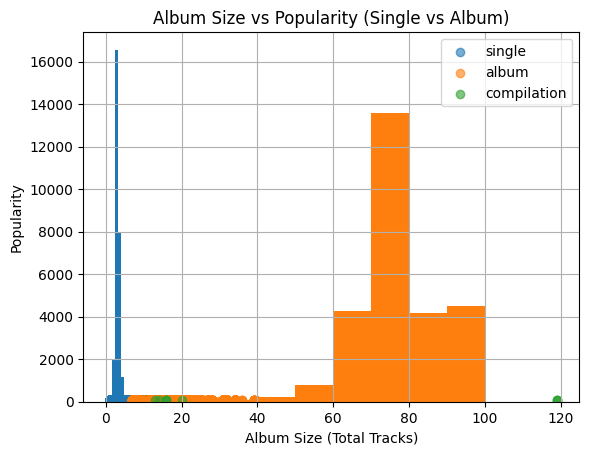

album_size_group
small         81.007648
medium        76.536049
large         73.051678
very large    68.622632
Name: popularity, dtype: float64
                 popularity   position
duration bucket                       
small             75.087336  29.973799
medium            76.592668  25.238580
large             77.792139  29.420386
album_type      album  compilation     single
rank_tier                                    
Top10       49.270665     0.000000  50.729335
Top25       48.824094     0.047996  51.127910
Top50       56.726409     0.035989  43.237602
duration bucket     small     medium     large
rank_tier                                     
Top10            0.522240  95.786062  3.691698
Top25            0.719942  94.804416  4.475642
Top50            1.007702  92.348665  6.643633
              total_tracks  popularity
total_tracks      1.000000   -0.342773
popularity       -0.342773    1.000000
None


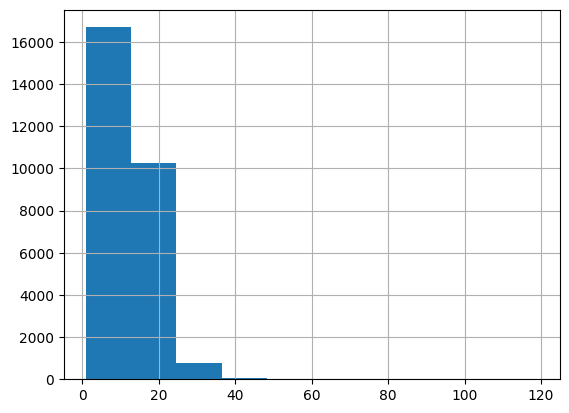

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Importing Dataset 
Data=pd.read_csv("Atlantic_France.csv")
# Checking For any null values and duplicate
Data.isnull().sum()
Data.duplicated().sum()

# Droping Duplicates
Data[Data.duplicated(keep=False)]
Data=Data.drop_duplicates()
print(Data.shape)

# Droping null value
Data=Data.dropna(subset=["song"])

# Converting milliseconds to seconds 
Data["duration_min"]=Data["duration_ms"]/60000

# Converting date to datetime
Data["date"]=pd.to_datetime(Data["date"],dayfirst=True)
Data.head()

# Standarlise Alumn type
Data["album_type"]=Data["album_type"].str.lower()

# Histogram of Duration_min and Popularity
Data["duration_min"].hist()
Data["popularity"].hist()

# Duration Bucket 
Data["duration bucket"]=pd.cut(
    Data["duration_min"],
    bins=[0,2,4,10],
    labels=["small","medium","large"]
)
Data.head()
#Explicit vs Non-Explicit Share
print(Data["is_explicit"].value_counts(normalize=True)*100)

# Checking 50 Entries per day 
daily_count=Data.groupby("date").size()
print(daily_count.value_counts())
print(daily_count[daily_count!=50])

# Rank tier filter (Top 10 / 25 / 50)
def Rank(pos):
    if pos<=10:
        return "Top10"
    elif pos<=25:
        return "Top25"
    else:
        return "Top50"
    
Data["rank_tier"]=Data["position"].apply(Rank)

# Rank-wise Explicit Distribution
print(Data.groupby("rank_tier")["is_explicit"].mean()*100)

#Explicit Flag Consistency
print(Data["is_explicit"].unique())

# Single vs Album Representation
print(Data["album_type"].value_counts())

# Rank-Based Format Comparison
print(pd.crosstab(Data["rank_tier"],Data["album_type"]))

# Popularity Comparison
print(Data.groupby("is_explicit")["popularity"].mean())

# Popularity Differences by Album Type
print(Data.groupby("album_type")["popularity"].mean())

# Album Size vs Popularity
groups = Data["album_type"].unique()

for t in groups:
    subset = Data[Data["album_type"] == t]
    plt.scatter(
        subset["total_tracks"],
        subset["popularity"],
        label=t,
        alpha=0.6
    )

plt.xlabel("Album Size (Total Tracks)")
plt.ylabel("Popularity")
plt.title("Album Size vs Popularity (Single vs Album)")
plt.legend()
plt.show()
#Album Size Distribution 
Data["total_tracks"].hist()

# Create Album bucket
Data["album_size_group"]=pd.cut(
    Data["total_tracks"],
    bins=[0,5,10,20,100],
    labels=["small","medium","large","very large"]
)
print(Data.groupby("album_size_group")["popularity"].mean())
Data.head()
# Duration vs popularity
print(Data.groupby("duration bucket")[["popularity", "position"]].mean())
Data.head()

# Album Type %
print(
    pd.crosstab(
        Data["rank_tier"],
        Data["album_type"],
        normalize="index"
    )*100
)

# Duration Profile
print(
    pd.crosstab(
        Data["rank_tier"],
        Data["duration bucket"],
        normalize="index"
    )*100
)
print(Data[["total_tracks","popularity"]].corr())


# KPI SECTION

# KPI 1: Explicit Content Share

# Question:

# How much of the playlist is explicit?

In [3]:
explicit_share = Data["is_explicit"].mean()*100
print("Explicit Content Share:", explicit_share)

Explicit Content Share: 56.25989920806336


# KPI 2: Clean Content Dominance Ratio
# Question:

# Are clean songs more than explicit songs?

In [4]:
clean_songs=(Data["is_explicit"]==False).sum()
explicit_songs=(Data["is_explicit"]==True).sum()
print("Clean Content Dominance ratio :",clean_songs/explicit_songs)

Clean Content Dominance ratio : 0.7774649689679443


# KPI 3: Single vs Album Preference
# Question:

# What dominates French charts?

In [10]:
Data["album_type"].value_counts(normalize=True)*100

album_type
album          52.865371
single         47.102232
compilation     0.032397
Name: proportion, dtype: float64

# KPI 4: Average Song Duration
# Question:
# What is the typical song length?

In [12]:
Data["duration_min"].mean()

np.float64(3.091343216942645)

# KPI 5: Album Size Impact Index
# Question:

# Do larger albums perform better?

In [18]:
pd.crosstab(
    Data["rank_tier"],
    Data["album_size_group"],
    normalize="index"
) * 100


album_size_group,small,medium,large,very large
rank_tier,,,,
Top10,49.594814,7.077256,37.439222,5.888709
Top25,48.781659,10.118833,36.382187,4.717321
Top50,41.272583,8.774203,41.078241,8.874973


# KPI 6: Content Acceptance Score 
# Question:

# Which rank tier has higher popularity?

In [15]:
Data.groupby("rank_tier")["popularity"].mean()

rank_tier
Top10    78.288133
Top25    77.758579
Top50    75.320377
Name: popularity, dtype: float64

In [8]:
print(Data.to_csv("Atlantic_France_Processed.csv", index=False))
import os

print(os.getcwd())
print(os.listdir())
Data.head()
print(Data["date"].dtype)

None
c:\Users\Madhav Suneja\OneDrive\Attachments\图片\Attachments\Desktop\France_Top50_Content_Intelligence
['App.py', 'Atlantic_France.csv', 'Atlantic_France_Processed.csv', 'France_Top50_Analysis.ipynb', 'venv']
datetime64[us]
